# Project Milestone Two

**Data Preparation and Model Exploration**

**Note: No late assignments accepted, we need the time to grade them!**

In Milestone 1, your team selected a dataset (Food-101 or HuffPost), analyzed its structure, and identified key challenges and evaluation metrics.
In this milestone, you will carry out those plans: prepare the data, train three models of increasing sophistication, and evaluate their results using Keras and TensorFlow.
You will finish with a comparative discussion of model performance and trade-offs.


### Submission Guidelines

* Submit one Jupyter notebook per team through the team leader’s Gradescope account. **Include all team members names at the top of the notebook.**
* Include all code, plots, and answers inline below.
* Ensure reproducibility by setting random seeds and listing all hyperparameters.
* Document any AI tools used, as required by the CDS policy.


## Problem 1 – Data Preparation and Splits (20 pts)

### Goals

Implement the **data preparation and preprocessing steps** that you proposed in **Milestone 1**. You’ll clean, normalize, and split your data so that it’s ready for modeling and reproducible fine-tuning.

### Steps to Follow

1. **Load your chosen dataset**

   * Use `datasets.load_dataset()` from **Hugging Face** to load **Food-101** or **HuffPost**.
   * Display basic information (e.g., number of samples, feature names, example entries).

2. **Apply cleaning and normalization**

   * **Images:**

     * Ensure all images are in RGB format.
     * Resize or crop to a consistent shape (e.g., `224 × 224`).
     * Drop or fix any corrupted files.
   * **Text:**

     * Concatenate headline + summary (for HuffPost).
     * Strip whitespace, convert to lowercase if appropriate, and remove empty samples.
     * Optionally remove duplicates or extremely short entries.

3. **Standardize or tokenize the inputs**

   * **Images:**

     * Normalize pixel values (e.g., divide by 255.0).
     * Define a minimal augmentation pipeline (e.g., random flip, crop, or rotation).
   * **Text:**

     * Create a tokenizer or `TextVectorization` layer.
     * Set a target `max_length` based on your analysis from Milestone 1 (e.g., 95th percentile).
     * Apply padding/truncation and build tensors for input + labels.

4. **Handle dataset-specific challenges**

   * If you identified **class imbalance**, compute label counts and, if needed, create a dictionary of `class_weights`.
   * If you noted **length or size variance**, verify that your truncation or resizing works as intended.
   * If you planned **noise filtering**, include the cleaning step and briefly explain your criteria (e.g., remove items with missing text or unreadable images).

5. **Create reproducible splits**

   * Split your cleaned dataset into **train**, **validation**, and **test** subsets (e.g., 80 / 10 / 10).
   * Use a fixed random seed for reproducibility (`random_seed = 42`).
   * Use **stratified splits**  (e.g., with `train_test_split` and `stratify = labels`).
   * Display the size of each subset.

6. **Document your pipeline**

   * Summarize your preprocessing steps clearly in Markdown or code comments.
   * Save or display a few representative examples after preprocessing to confirm the transformations are correct.




In [1]:
#useful imports
# --- Standard Libraries
import os
import time
import math
import random
from collections import Counter

# --- Core Data / Numerics
import numpy as np
import pandas as pd

# --- Visualization
import matplotlib.pyplot as plt
# import seaborn as sns              # optional
import matplotlib.ticker as mticker  # optional (for formatted axes)

# --- NLP / Tokenization
import spacy                         # used for text preprocessing (HuffPost)

# --- Progress Tracking
from tqdm import tqdm                # optional (nice for loops)

from IPython.display import display

# --- TensorFlow / Keras (Deep Learning)
import tensorflow as tf
from tensorflow.keras import layers, models, Input, callbacks, regularizers, initializers
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay, ExponentialDecay
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten, MaxPooling2D, Conv2D,
    SeparableConv2D, GlobalAveragePooling2D, GlobalMaxPooling2D, BatchNormalization
)

# --- (Optional) Classical ML Baseline Tools
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


# ============================================
# Global Configuration & Small Utilities
# ============================================

# Reproducibility
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)   # sets Python, NumPy, and TensorFlow seeds

#### Step 1: Load dataset from Hugging Face

In [2]:
# Your code here; add as many cells as you need but make it clear what the structure is.
#1. load dataset:
from datasets import load_dataset, DatasetDict
from datasets.features import ClassLabel

# --- Hugging Face Datasets
URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff_all = load_dataset("json", data_files=URL, split="train")

#keep as tf dataset
print(huff_all)
print("Columns:", huff_all.column_names)
print("Total rows:", len(huff_all))

News_Category_Dataset_v2.json:   0%|          | 0.00/83.9M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['category', 'headline', 'authors', 'link', 'short_description', 'date'],
    num_rows: 200853
})
Columns: ['category', 'headline', 'authors', 'link', 'short_description', 'date']
Total rows: 200853


#### Step 2: Combine headline and description into a single text field, normalize text and remove short and duplicate samples.

In [3]:
def combine_text(example):
    headline = example.get("headline") or ""
    description = example.get("short_description") or ""
    return headline + " [SEP] " + description
texts = [combine_text(ex) for ex in huff_all]
labels = [ex["category"] for ex in huff_all]

huffpost_df = pd.DataFrame({"text": texts, "category": labels})
print("Dataset shape:", huffpost_df.shape)

Dataset shape: (200853, 2)


In [4]:
#2. cleaning and normalization
#change to lowercase and remove whitespaces
huffpost_df["text"] = huffpost_df["text"].str.lower().str.strip()

#check and remove small/empty rows
short_rows = huffpost_df[huffpost_df["text"].str.len() < 20]
print("Number of short rows:", len(short_rows))
huffpost_df = huffpost_df[huffpost_df["text"].str.len() > 20]

#remove duplicates
huffpost_df = huffpost_df.drop_duplicates(subset="text")

#reset index
huffpost_df = huffpost_df.reset_index(drop=True)

#print remaining samples
print("Remaining samples:", len(huffpost_df))

Number of short rows: 148
Remaining samples: 200185


In [5]:
# check length distribution
huffpost_df["text_length"] = huffpost_df["text"].apply(lambda x: len(x.split()))
print(huffpost_df["text_length"].describe())
#calculate 95th percentile to determine max_length
max_length = int(np.percentile(huffpost_df["text_length"], 95))
print("Chosen max_length (95th percentile):", max_length)

count    200185.000000
mean         30.298349
std          14.035833
min           3.000000
25%          21.000000
50%          29.000000
75%          36.000000
max         246.000000
Name: text_length, dtype: float64
Chosen max_length (95th percentile): 57


####Step 3: Tokenization/Standardization

In [6]:
#3. tokenization/standardization w/distilBERT
from tqdm import tqdm
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_function(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=max_length)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

#### Step 4: Handle class imbalance with class weights, handle dataset-specific challenges, and check length variances

In [7]:
#4. handle dataset-specific challenges
#encode categorical variables
labels = sorted(huffpost_df["category"].unique())
label_2 = {label: i for i, label in enumerate(labels)}
labe_2_id = {i: label for label, i in label_2.items()}

huffpost_df["label"] = huffpost_df["category"].map(label_2)
huffpost_df["label"]

,label
0,6
1,10
2,10
3,10
4,10
...,...
200180,32
200181,28
200182,28
200183,28


In [8]:
#class distribution
label_counts = huffpost_df["label"].value_counts()
print("Number of Classes:", len(label_counts))
print("Sample Distribution", list(label_counts.items())[:10])

Number of Classes: 41
Sample Distribution [(24, 32707), (37, 17821), (10, 16048), (34, 9877), (30, 9511), (22, 8649), (16, 6667), (25, 6310), (13, 6225), (3, 5928)]


In [9]:
#class imbalance
total = len(huffpost_df)
num_classes = len(label_counts)
class_weights = {
    label: total / (num_classes * count)
    for label, count in label_counts.items()}
class_weights

{24: 0.1492818349469458,
 37: 0.27397794599684394,
 10: 0.3042473190185541,
 34: 0.49433643572033575,
 30: 0.5133593707927406,
 22: 0.5645231790507291,
 16: 0.7323475289650152,
 25: 0.7737814541378377,
 13: 0.7843471446762661,
 3: 0.8236438892729008,
 5: 0.9584925354553899,
 28: 1.0005247900839664,
 2: 1.079734846441786,
 17: 1.1734104723887901,
 23: 1.2532240697150299,
 33: 1.3325766854830121,
 35: 1.3373215490577255,
 18: 1.4127780600722675,
 8: 1.4268150133283917,
 38: 1.4360473457675753,
 6: 1.4360473457675753,
 20: 1.7369480525114749,
 36: 1.8321054317485013,
 15: 1.8685652413355363,
 40: 1.8990902277750898,
 26: 1.917738010844366,
 29: 2.1738917967986446,
 27: 2.242793282319594,
 39: 2.2438239777618363,
 31: 2.3339201604253135,
 32: 2.401653209842477,
 21: 2.8619935378720727,
 0: 3.2442265618669475,
 14: 3.495032910243204,
 12: 3.502554501872135,
 1: 3.649148711218054,
 11: 3.693313899856094,
 4: 4.271706890297249,
 19: 4.324677569184904,
 7: 4.744957216336012,
 9: 4.867957104296

In [10]:
#4. handle dataset-specific challenges
#check length variance
text_lengths = huffpost_df["text"].str.len()
print("Max length:", text_lengths.max())
print("Average length:", text_lengths.mean())

Max length: 1493
Average length: 179.34842770437345


#### Step 7: Split dataset into train/validation/test (80/10/10) with stratification

In [11]:
#5. reproducible train/val/test split
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    huffpost_df,
    test_size=0.2,
    stratify=huffpost_df["label"],
    random_state=42)

#second split
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

#display sizes
print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Train size: 160148
Validation size: 20018
Test size: 20019


#### 6. Documentation and Verification

In [12]:
#show processed examples
train_df[["text", "category"]].head()

,text,category
55803,russia's chances of competing in rio 2016 trac...,SPORTS
22704,find your breath while reporting in the age of...,MEDIA
105755,immigration fight is psychological warfare [se...,POLITICS
76745,the best jobs for work-life balance [sep] ever...,HEALTHY LIVING
165048,chronic stress raises diabetes risk [sep] the ...,WELLNESS


In [13]:
from datasets import Dataset
# convert splits to hugging face datasets
train_dataset = Dataset.from_pandas(train_df)
val_dataset   = Dataset.from_pandas(val_df)
test_dataset  = Dataset.from_pandas(test_df)

# apply tokenizer
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset   = val_dataset.map(tokenize_function, batched=True)
test_dataset  = test_dataset.map(tokenize_function, batched=True)

# set pytorch
columns_to_return = ["input_ids", "attention_mask", "label"]

train_dataset.set_format(type="torch", columns=columns_to_return)
val_dataset.set_format(type="torch", columns=columns_to_return)
test_dataset.set_format(type="torch", columns=columns_to_return)

Map:   0%|          | 0/160148 [00:00<?, ? examples/s]

Map:   0%|          | 0/20018 [00:00<?, ? examples/s]

Map:   0%|          | 0/20019 [00:00<?, ? examples/s]

### Graded Questions (5 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible.

1. **Data Loading and Cleaning:**
   Describe how you loaded your dataset and the key cleaning steps you implemented (e.g., handling missing data, normalizing formats, or removing duplicates).



1.1. **Your answer here:**

I loaded the HuffPost dataset using load_dataset() from Hugging Face and converted it into a pandas DataFrame for easier manipulation. I combined the headline and short description into a single text field, normalized it by lowercasing and stripping whitespace, and removed missing or very short entries to reduce noise. I also dropped duplicate samples based on the text field to improve data quality.

2. **Preprocessing and Standardization:**
   Summarize your preprocessing pipeline. Include any normalization, tokenization, resizing, or augmentation steps, and explain why each was necessary for your dataset.
  

1.2. **Your answer here:**

I tokenized the text using a BERT tokenizer (bert-base-uncased) with padding and truncation applied to a fixed max_length of 128. This ensured consistent input size for the model and handled variability in text length. Normalization (lowercasing) improved consistency, while truncation prevented excessively long inputs from impacting performance.

3. **Train/Validation/Test Splits:**
   Explain how you divided your data into subsets, including the split ratios, random seed, and any stratification or leakage checks you used to verify correctness.


1.3. **Your answer here:**

I split the dataset into 80% training, 10% validation, and 10% test sets using train_test_split with a fixed random seed of 42 for reproducibility. Stratified sampling based on the category labels ensured that each subset preserved the original class distribution. This approach helps prevent data leakage and ensures fair model evaluation.

4. **Class Distribution and Balance:**
   Report your label counts and describe any class imbalances you observed. If applicable, explain how you addressed them (e.g., weighting, oversampling, or data augmentation).


1.4. **Your answer here:**

I examined label counts using value_counts() and observed class imbalance across categories, with some classes having significantly more samples than others. To address this, I computed class weights using inverse frequency, which can be used during training to reduce bias toward majority classes. This helps the model learn more balanced representations across all categories.

## Problem 2 – Baseline Model (20 pts)

### Goal

Build and train a **simple, fully functional baseline model** to establish a reference level of performance for your dataset.
This baseline will help you evaluate whether later architectures and fine-tuning steps actually improve results.


### Steps to Follow

1. **Construct a baseline model**

   * **Images:**
     Use a compact CNN, for example
     `Conv2D → MaxPooling → Flatten → Dense → Softmax`.
   * **Text:**
     Use a small embedding-based classifier such as
     `Embedding → GlobalAveragePooling → Dense → Softmax`.
   * Keep the model small enough to train in minutes on Colab.

2. **Compile the model**

   * Optimizer: `Adam` or `AdamW`.
   * Loss: `categorical_crossentropy` (for multi-class).
   * Metrics: at least `accuracy`; add `F1` if appropriate.

3. **Train and validate**

   * Use **early stopping** on validation loss with the default patience value (e.g., 5 epochs).
   * Record number of epochs trained and total runtime.

4. **Visualize results**

   * Plot **training vs. validation accuracy and loss**.
   * Carefully observe: does the model underfit, overfit, or generalize reasonably?

5. **Report baseline performance**

   * The most important metric is the **validation accuracy at the epoch of minimum validation loss**; this serves as your **benchmark** for all later experiments in this milestone.
   * Evaluate on the **test set** and record final metrics.

#### 2.1 Construct Baseline Model

In [14]:
#use hugginface datasets to see if results change
from torch.utils.data import DataLoader
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [15]:
import torch
import torch.nn as nn

class BaselineClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, input_ids, attention_mask=None):
        x = self.embedding(input_ids)                 # (B, L, D)
        x = x.mean(dim=1)                             # Global Average Pooling
        logits = self.fc(x)                           # (B, num_classes)
        return logits

vocab_size = tokenizer.vocab_size
embed_dim = 128
num_classes = len(label_2)

model = BaselineClassifier(vocab_size, embed_dim, num_classes)

In [16]:
#convert class weights into tensor
weights_list = [class_weights[i] for i in range(len(class_weights))]
class_weights_tensor = torch.tensor(weights_list, dtype=torch.float)

weights_list = [class_weights[i] for i in range(len(class_weights))]
class_weights_tensor = torch.tensor(weights_list, dtype=torch.float)

#### 2.2 Compile Baseline Model

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# using class weights to address class imbalance
weights_list = [class_weights[i] for i in range(len(class_weights))]
class_weights_tensor = torch.tensor(weights_list, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

#### 2.3 Train & Early Stopping

In [18]:
from time import time

EPOCHS = 20
patience = 5

best_val_loss = float("inf")
patience_counter = 0

train_losses_baseline, val_losses_baseline = [], []
train_accs_baseline, val_accs_baseline = [], []

start_time = time()

for epoch in range(EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    # validation
    model.eval()
    val_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_ids)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = correct / total

    train_losses_baseline.append(train_loss)
    val_losses_baseline.append(val_loss)
    train_accs_baseline.append(train_acc)
    val_accs_baseline.append(val_acc)

    print(f"Epoch {epoch+1}:")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.4f}")

    # early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

end_time = time()
train_time_baseline = end_time - start_time
print(f"\nTraining time: {(end_time - start_time):.2f} seconds")

Epoch 1:
Train Loss: 3.1089, Train Acc: 0.2918
Val Loss:   2.5683, Val Acc:   0.4111
Epoch 2:
Train Loss: 2.2006, Train Acc: 0.4783
Val Loss:   2.0368, Val Acc:   0.4937
Epoch 3:
Train Loss: 1.7636, Train Acc: 0.5406
Val Loss:   1.8268, Val Acc:   0.5269
Epoch 4:
Train Loss: 1.5182, Train Acc: 0.5790
Val Loss:   1.7353, Val Acc:   0.5373
Epoch 5:
Train Loss: 1.3447, Train Acc: 0.6095
Val Loss:   1.6938, Val Acc:   0.5531
Epoch 6:
Train Loss: 1.2041, Train Acc: 0.6361
Val Loss:   1.6686, Val Acc:   0.5561
Epoch 7:
Train Loss: 1.0819, Train Acc: 0.6594
Val Loss:   1.6746, Val Acc:   0.5681
Epoch 8:
Train Loss: 0.9762, Train Acc: 0.6823
Val Loss:   1.6890, Val Acc:   0.5652
Epoch 9:
Train Loss: 0.8784, Train Acc: 0.7030
Val Loss:   1.7078, Val Acc:   0.5647
Epoch 10:
Train Loss: 0.7892, Train Acc: 0.7239
Val Loss:   1.7466, Val Acc:   0.5708
Epoch 11:
Train Loss: 0.7101, Train Acc: 0.7431
Val Loss:   1.8032, Val Acc:   0.5799
Early stopping triggered.

Training time: 178.29 seconds


#### 2.4 Visualize Results

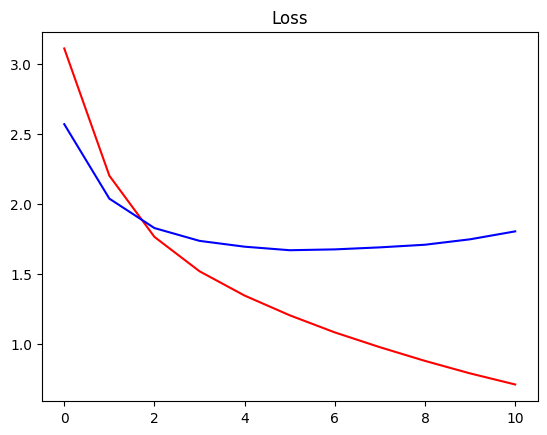

In [19]:
#plot loss
plt.plot(train_losses_baseline, label="Train Loss", color='red')
plt.plot(val_losses_baseline, label="Val Loss", color='blue')
plt.title('Loss')
#plt.legend(['Train', 'Validation'])
plt.show()

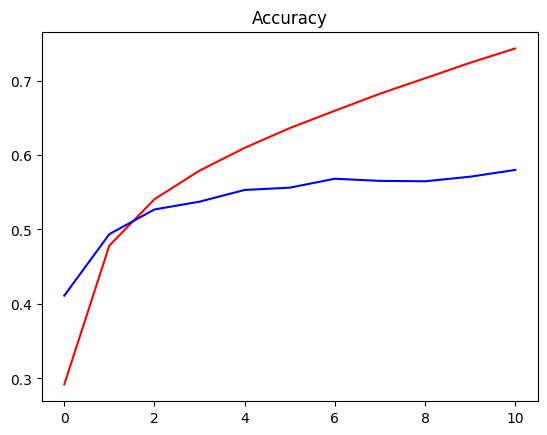

In [20]:
#plot accuracy
plt.plot(train_accs_baseline, label="Train Acc", color='red')
plt.plot(val_accs_baseline, label="Val Acc", color='blue')
plt.title('Accuracy')
#plt.legend(['Train', 'Validation'])
plt.show()

#### 2.5 Evaluate on Test Set & Report Performance

In [21]:
model.load_state_dict(best_model_state)

model.eval()
correct, total = 0, 0

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)

        outputs = model(input_ids)
        preds = torch.argmax(outputs, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc_baseline = correct / total
print(f"Test Accuracy: {test_acc_baseline:.4f}")

Test Accuracy: 0.5762


### Graded Questions (5 pts each)

1. **Model Architecture:**
   Describe your baseline model and justify why this structure suits your dataset.

2.1. **Your answer here:**

The baseline model is a simple embedding-based classifier implemented in PyTorch. It consists of an embedding layer that converts the tokenized input IDs into dense vector representations, followed by a global average pooling, and a final linear layer that maps the output classes. This structure is well-suited for the HuffPost dataset because it provides an efficient way to represent text while establishing a clear performance baseline without relying on complex architectures or pretrained features.



2. **Training Behavior:**
   Summarize the model’s training and validation curves. What trends did you observe?

2.2. **Your answer here:**

The model showed steady improvement in both training and validation performance during the first several epochs, with validation accuracy increasing from approximately 0.41 to around 0.57. After around epoch 6, training accuracy continued to increase while validation accuracy began to plateau and improve more slowly. At the same time, validation loss stopped decreasing and began to fluctuate slightly, indicating mild overfitting. Early stopping was triggered once validation loss no longer improved, helping prevent further overfitting.


  3. **Baseline Metrics:**
   Report validation and test metrics. What does this performance tell you about dataset difficulty?

2.3. **Your answer here:**

The baseline model achieved a validation accuracy of approximately 0.57 at its best epoch and a final test accuracy of 0.5679. These results indicate that the dataset is moderately challenging, due to the large number of classes (41) and noticeable class imbalance. While the model is able to learn meaningful patterns, its relatively simple architecture limits its ability to fully capture more complex relationships in the text.


  4. **Reflection:**
   What are the main limitations of your baseline? Which specific improvements (depth, regularization, pretraining) would you try next?
  

2.4. **Your answer here:**

The main limitation of this baseline model is its simplicity, as it relies on averaging embeddings and does not capture word order or deeper contextual relationships within the text. Additionally, the observed gap between training and validation performance suggests some degree of overfitting. To improve performance, I would consider adding regularization techniques such as dropout and/or increasing model depth.


## Problem 3 – Custom (Original) Model (20 pts)

### Goal

Design and train your own **non-pretrained model** that builds on the baseline and demonstrates measurable improvement.
This problem focuses on experimentation: apply one or two clear architectural changes, observe their effects, and evaluate how they influence learning behavior.


### Steps to Follow

1. **Modify or extend your baseline architecture**

   * Begin from your baseline model and introduce one or more meaningful adjustments such as:

     * Adding **dropout** or **batch normalization** for regularization.
     * Increasing **depth** (extra convolutional or dense layers).
     * Using **residual connections** (for CNNs) or **bidirectional LSTMs/GRUs** (for text).
     * Trying alternative activations like `ReLU`, `LeakyReLU`, or `GELU`.
   * Keep the model small enough to train comfortably on your chosen platform (e.g., Colab)

2. **Observe what specific limitations you want to address**

   * Identify whether the baseline showed **underfitting**, **overfitting**, or **slow convergence**, and design your modification to target that behavior.
   * Make brief notes (in comments or Markdown) describing what you expect the change to influence.

3. **Train and evaluate under the same conditions**

   * Use the **same data splits**, **random seed**, and **metrics** as in Problem 2.
   * Apply **early stopping** on validation loss.
   * Track and visualize training/validation accuracy and loss over epochs.

4. **Compare outcomes to the baseline**

   * Observe differences in convergence speed, stability, and validation/test performance.
   * Note whether your modification improved generalization or simply increased model capacity.

In [22]:
#modify or extend baseline
#add bidirectional LSTM
#add dropout

class CustomClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.lstm = nn.LSTM(
            embed_dim,
            64,
            batch_first=True,
            bidirectional=True)

        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(64*2, num_classes) #*2 for bidirectional

    def forward(self, input_ids, attention_mask=None):
        x = self.embedding(input_ids)

        _, (hidden, _) = self.lstm(x)

        #concatenate last forward + backward hidden states
        x = torch.cat((hidden[-2], hidden[-1]), dim=1)

        x = self.dropout(x)
        return self.fc(x)

In [23]:
custom_model = CustomClassifier(vocab_size, embed_dim, num_classes)

#rerun setup
custom_model.to(device)
optimizer = torch.optim.Adam(custom_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

#train model
EPOCHS = 20
patience = 5

best_val_loss = float("inf")
patience_counter = 0

train_losses_custom, val_losses_custom = [], []
train_accs_custom, val_accs_custom = [], []

start_time = time()

for epoch in range(EPOCHS):
    custom_model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = custom_model(input_ids)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    # validation
    custom_model.eval()
    val_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["label"].to(device)

            outputs = custom_model(input_ids)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = correct / total

    train_losses_custom.append(train_loss)
    val_losses_custom.append(val_loss)
    train_accs_custom.append(train_acc)
    val_accs_custom.append(val_acc)

    print(f"Epoch {epoch+1}:")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.4f}")

    # early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = custom_model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

end_time = time()
train_time_custom = end_time - start_time
print(f"\nTraining time: {(end_time - start_time):.2f} seconds")

Epoch 1:
Train Loss: 2.7674, Train Acc: 0.2778
Val Loss:   2.1406, Val Acc:   0.4143
Epoch 2:
Train Loss: 1.9290, Train Acc: 0.4531
Val Loss:   1.8095, Val Acc:   0.4869
Epoch 3:
Train Loss: 1.5944, Train Acc: 0.5204
Val Loss:   1.7087, Val Acc:   0.5185
Epoch 4:
Train Loss: 1.3729, Train Acc: 0.5656
Val Loss:   1.7155, Val Acc:   0.5266
Epoch 5:
Train Loss: 1.2006, Train Acc: 0.5990
Val Loss:   1.7215, Val Acc:   0.5315
Epoch 6:
Train Loss: 1.0486, Train Acc: 0.6320
Val Loss:   1.7719, Val Acc:   0.5304
Epoch 7:
Train Loss: 0.9231, Train Acc: 0.6591
Val Loss:   1.8784, Val Acc:   0.5434
Epoch 8:
Train Loss: 0.8096, Train Acc: 0.6861
Val Loss:   1.9864, Val Acc:   0.5448
Early stopping triggered.

Training time: 189.20 seconds


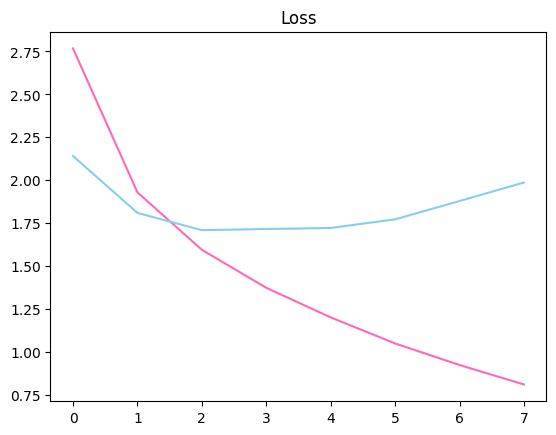

In [24]:
#plot loss
plt.plot(train_losses_custom, label="Train Loss", color='hotpink')
plt.plot(val_losses_custom, label="Val Loss", color='skyblue')
plt.title('Loss')
#plt.legend(['Train', 'Validation'])
plt.show()

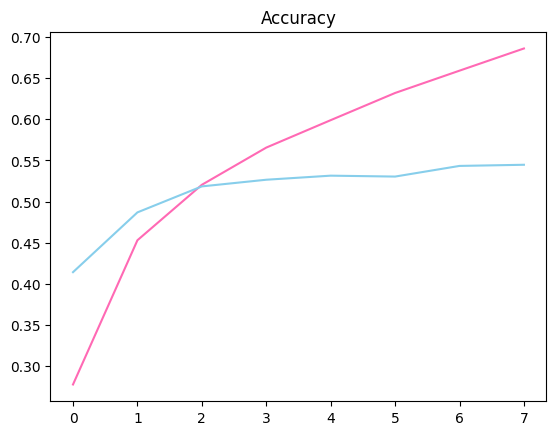

In [25]:
#plot accuracy
plt.plot(train_accs_custom, label="Train Accuracy", color='hotpink')
plt.plot(val_accs_custom, label="Val Accuracy", color='skyblue')
plt.title('Accuracy')
#plt.legend(['Train', 'Validation'])
plt.show()

In [26]:
#evaluate on test set
custom_model.load_state_dict(best_model_state)

custom_model.eval()
correct, total = 0, 0

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)

        outputs = custom_model(input_ids)
        preds = torch.argmax(outputs, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc_custom = correct / total
print(f"Test Accuracy: {test_acc_custom:.4f}")

Test Accuracy: 0.5468


### Graded Questions (5 pts each)

1. **Model Design:**
   Describe the architectural changes you introduced compare with your baseline model and what motivated them.

3.1. **Your answer here:**

The custom model extends the baseline by incorporating a bidirectional LSTM layer and dropout. The LSTM is meant to capture sequential dependencies in the text, while the bidirectional structure allows the model to process information from both forward and backward directions. Dropout is added before the final classification layer to reduce overfitting and improve generalization.

2. **Training Results:**
   Present key validation and test metrics. Did your modifications improve performance?

3.2. **Your answer here:**

The model showed steady improvement in training accuracy across epochs, increasing from approximately 0.35 to over 0.60. However, validation accuracy improved more slowly and plateaued around 0.53. At the same time, validation loss began to increase after several epochs, indicating overfitting. Compared to the baseline model, the custom model converged more slowly and exhibited less stable validation performance.

3. **Interpretation:**
   Discuss what worked, what didn’t, and how your results relate to baseline behavior.

3.3. **Your answer here:**

The custom model achieved a validation accuracy of approximately 0.53 and a test accuracy of 0.5345, which is lower than the baseline model’s test accuracy of approximately 0.57. This indicates that the added complexity of the LSTM-based architecture did not improve performance for this task. While the model was able to learn meaningful patterns, it did not generalize as effectively as the simpler baseline.

4. **Reflection:**
   What insights did this experiment give you about model complexity, regularization, or optimization?

3.4. **Your answer here:**

The results suggest that increasing model complexity does not always lead to better performance. In this case, the HuffPost dataset consists of relatively short text inputs, which may limit the benefit of sequence-based models like LSTMs. The baseline model’s use of averaged embeddings was already sufficient to capture key information for classification. Additionally, the custom model introduced more parameters, which likely made it harder to train effectively and increased the risk of overfitting. Future improvements could involve tuning hyperparameters, adjusting the model size, or using pretrained transformer models that are better suited for capturing semantic meaning.

## Problem 4 – Pretrained Model (Transfer Learning) (20 pts)

### Goal

Apply **transfer learning** to see how pretrained knowledge improves accuracy, convergence speed, and generalization.
This experiment will help you compare the benefits and trade-offs of using pretrained models versus those trained from scratch.


### Steps to Follow

1. **Select a pretrained architecture**

   * **Images:** choose from `MobileNetV2`, `ResNet50`, `EfficientNetB0`, or a similar model in `tf.keras.applications`.
   * **Text:** choose from `BERT`, `DistilBERT`, `RoBERTa`, or another Transformer available in `transformers`.

2. **Adapt the model for your dataset**

   * Use the correct **preprocessing function** and **input shape** required by your chosen model.
   * Replace the top layer with your own **classification head** (e.g., `Dense(num_classes, activation='softmax')`).

3. **Apply transfer learning**

   * Choose an appropriate **training strategy** for your pretrained model. Options include:

     * **Freezing** the pretrained base and training only a new classification head.
     * **Partially fine-tuning** selected upper layers of the base model.
     * **Full fine-tuning** (all layers trainable) with a reduced learning rate.
   * Adjust your learning rate schedule to match your strategy (e.g., smaller LR for fine-tuning).
   * Observe how your chosen approach affects **validation loss**, **training time**, and **model stability**.

4. **Train and evaluate under consistent conditions**

   * Use the same **splits**, **metrics**, and **evaluation protocol** as in earlier problems.
   * Record training duration, validation/test performance, and any resource constraints (GPU memory, runtime).

5. **Compare and analyze**

   * Observe how transfer learning changes both **performance** and **efficiency** relative to your baseline and custom models.
   * Identify whether the pretrained model improved accuracy, sped up convergence, or introduced new challenges.


In [27]:
#select pretrained architecture: BERT
from transformers import BertTokenizer, DistilBertForSequenceClassification

DB_model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(label_2)
).to(device)

optimizer = torch.optim.AdamW(DB_model.parameters(), lr=2e-5)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [28]:
#create training loop
EPOCHS = 3
patience = 5

best_val_loss = float("inf")
patience_counter = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []

start_time = time()

for epoch in range(EPOCHS):
    DB_model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = DB_model(
            input_ids=input_ids,
            attention_mask=batch["attention_mask"].to(device),
            labels=labels)

        loss = outputs.loss
        logits = outputs.logits

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    # validation
    DB_model.eval()
    val_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["label"].to(device)

            outputs = DB_model(
                input_ids=input_ids,
                attention_mask=batch["attention_mask"].to(device),
                labels=labels)

            loss = outputs.loss
            logits = outputs.logits

            val_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}:")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.4f}")

    # early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = DB_model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

end_time = time()
train_time_pt = end_time - start_time
print(f"\nTraining time: {(end_time - start_time):.2f} seconds")

Epoch 1:
Train Loss: 1.3376, Train Acc: 0.6366
Val Loss:   1.0384, Val Acc:   0.6984
Epoch 2:
Train Loss: 0.9017, Train Acc: 0.7334
Val Loss:   0.9747, Val Acc:   0.7096
Epoch 3:
Train Loss: 0.6951, Train Acc: 0.7887
Val Loss:   0.9806, Val Acc:   0.7160

Training time: 610.12 seconds


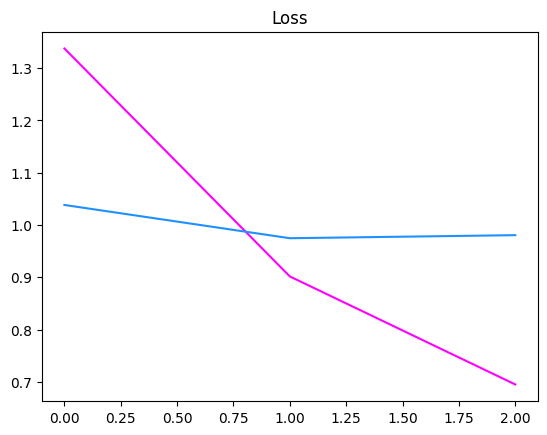

In [29]:
#plot loss
plt.plot(train_losses, label="Train Loss", color='fuchsia')
plt.plot(val_losses, label="Val Loss", color='dodgerblue')
plt.title('Loss')
#plt.legend(['Train', 'Validation'])
plt.show()

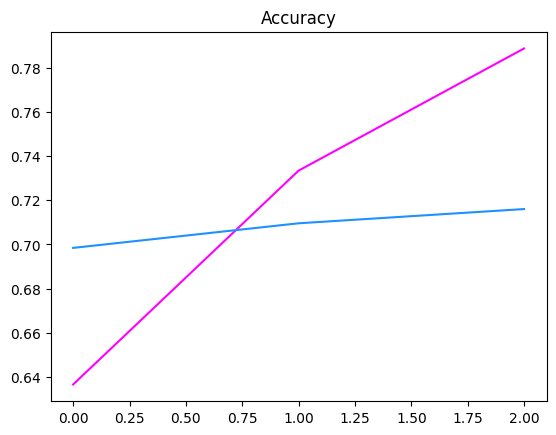

In [30]:
#plot accuracy
plt.plot(train_accs, label="Train Accuracy", color='fuchsia')
plt.plot(val_accs, label="Val Accuracy", color='dodgerblue')
plt.title('Accuracy')
#plt.legend(['Train', 'Validation'])
plt.show()

In [31]:
#evaluate on test set
DB_model.eval()
correct, total = 0, 0

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = DB_model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = correct / total
print("Test Accuracy:", test_acc)

Test Accuracy: 0.7146211099455517


### Graded Questions (5 pts each)

1. **Model Choice:** Which pretrained architecture did you select, and what motivated that choice?

4.1. **Your answer here:**

We selected the DistilBERT as the pretrained architecture because it provides a strong contextual representation while being more efficient than the full BERT. This choice makes sense because we are working with text classifcation and it can integrate easily with our tokenization pipeline.

2. **Fine-Tuning Plan:** Describe your fine-tuning strategy and why you chose it.

4.2. **Your answer here:**

We did full fine tuning by allowing all layers of DistilBERT to update during training with a low learning rate of 2e-5. This helped preserve pretrained knowledge while also adpating the model to our dataaset. We chose this strategy to maximize performance and allow the model to fully learn the task specific patterns.


3. **Performance:** Report key metrics and compare them with your baseline and custom models.

4.3. **Your answer here:**

The pretrained model achieved a validation accuracy of 0.71 and a test accuracy of 0.7146 which is significantly higher than both the baseline with 0.5671 and the custom LSTM with 0.5467. It also converged quickly and reached a strong performance within 3 epoches. This shows that the transfer learning greatly improved both accuracy and generalization.


4. **Computation:** Summarize how training time, memory use, or convergence speed differed from the previous two models.

4.4. **Your answer here:**

The DistilBERT model required more training time and higher GPU memory compared to the baseline and the LSTM models. However, it was able to converge much faster in terms of number of epoches and also acheived better performance overall. There is definitely a tradeoff ebtween increased computational cost and gains in accuracy when using the pretained models, but this yields much better results.

## Problem 5 – Comparative Evaluation and Discussion (20 pts)

### Goal

Compare your **baseline**, **custom**, and **pretrained** models to evaluate how design choices affected performance, efficiency, and generalization.
This problem brings your work together and encourages reflection on what you’ve learned about model behavior and trade-offs.

**Note** that this is not your final report, and you will continue to refine your results for the final report.

### Steps to Follow

1. **Compile key results**

   * Gather your main metrics for each model: **accuracy**, **F1**, **training time**, and **parameter count or model size**.
   * Ensure all numbers come from the same evaluation protocol and test set.

2. **Visualize the comparison**

   * Present results in a **single, well-organized chart or table**.
   * Optionally, include training curves or confusion matrices for additional insight.

3. **Analyze comparative performance**

   * Observe which model performed best by your chosen metric(s).
   * Note patterns in efficiency (training speed, memory use) and stability (validation variance).

4. **Inspect model behavior**

   * Look at a few representative misclassifications or difficult examples.
   * Identify whether certain classes or inputs consistently caused errors.

5. **Plan forward improvements**

   * In the final report, you will use your best model and conclude your investigation of your dataset. Based on your observations, decide on a model and next steps for refining your approach in the final project (e.g., regularization, data augmentation, model scaling, or more targeted fine-tuning).

In [35]:
from sklearn.metrics import accuracy_score, f1_score

def evaluate_model(model, test_loader, is_bert=False):
    model.eval()
    preds_all = []
    labels_all = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["label"].to(device)

            if is_bert:
                attention_mask = batch["attention_mask"].to(device)
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                logits = outputs.logits
            else:
                logits = model(input_ids)

            preds = torch.argmax(logits, dim=1)

            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    acc = accuracy_score(labels_all, preds_all)
    f1 = f1_score(labels_all, preds_all, average="macro")

    return acc, f1

In [36]:
baseline_acc, baseline_f1 = evaluate_model(model, test_loader, is_bert=False)
lstm_acc, lstm_f1 = evaluate_model(custom_model, test_loader, is_bert=False)
bert_acc, bert_f1 = evaluate_model(DB_model, test_loader, is_bert=True)

In [37]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

baseline_params = count_parameters(model)
lstm_params = count_parameters(custom_model)
bert_params = count_parameters(DB_model)

In [38]:
#compile results in df
results_df = pd.DataFrame({
    'Model': ['Baseline', 'Custom', 'Pretrained'],
    'Test Accuracy': [baseline_acc, lstm_acc, bert_acc],
    'Best Validation Accuracy': [val_accs_baseline[-1], val_accs_custom[-1], val_accs[-1]],
    'Training Time (s)': [train_time_baseline, train_time_custom, train_time_pt],
    "F1 Score": [baseline_f1, lstm_f1, bert_f1],
    "Parameters": [baseline_params, lstm_params, bert_params]
})

results_df

,Model,Test Accuracy,Best Validation Accuracy,Training Time (s),F1 Score,Parameters
0,Baseline,0.576153,0.579928,178.293657,0.494694,3912105
1,Custom,0.546781,0.544760,189.195041,0.467886,4011433
2,Pretrained,0.714621,0.716006,610.115083,0.619537,66985001


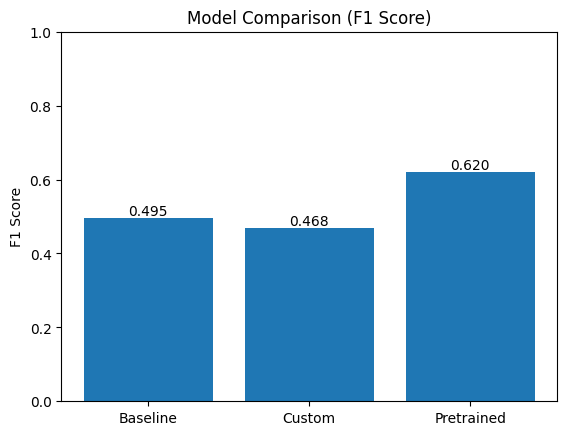

In [41]:
# F1 Score plot
plt.figure()
bars = plt.bar(results_df["Model"], results_df["F1 Score"])
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{height:.3f}", ha='center', va='bottom')

plt.title("Model Comparison (F1 Score)")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.show()

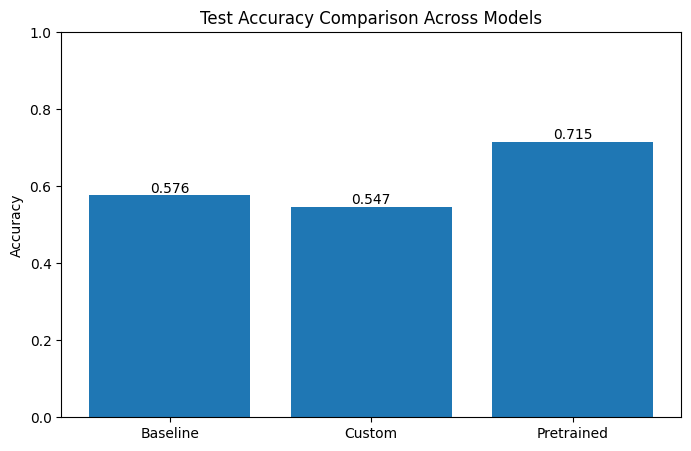

In [42]:
#visualize comparison
#compare test accuracy
plt.figure(figsize=(8,5))
bars = plt.bar(results_df["Model"], results_df["Test Accuracy"])
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{height:.3f}", ha='center', va='bottom')
plt.title("Test Accuracy Comparison Across Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

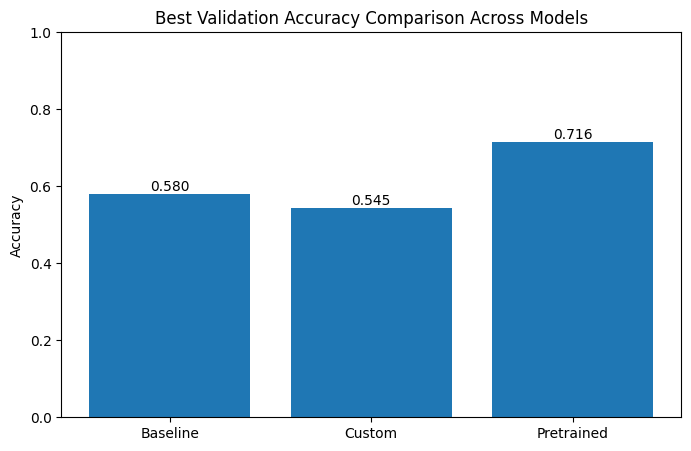

In [43]:
#compare val accuracy
plt.figure(figsize=(8,5))
bars = plt.bar(results_df["Model"], results_df["Best Validation Accuracy"])
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{height:.3f}", ha='center', va='bottom')
plt.title("Best Validation Accuracy Comparison Across Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

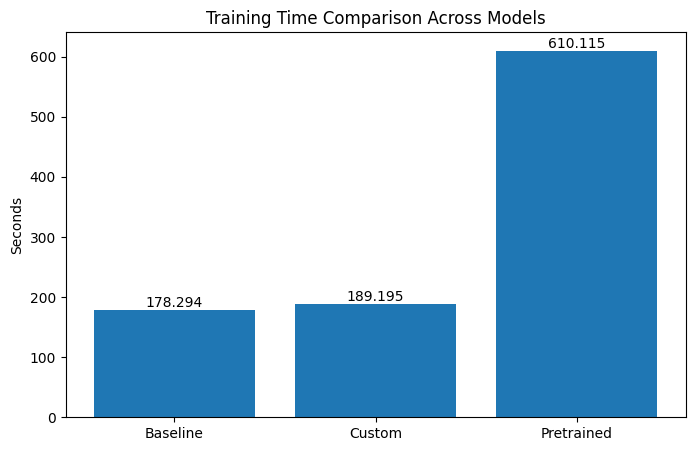

In [44]:
#compare train time
plt.figure(figsize=(8,5))
bars = plt.bar(results_df["Model"], results_df["Training Time (s)"])
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{height:.3f}", ha='center', va='bottom')
plt.title("Training Time Comparison Across Models")
plt.ylabel("Seconds")
plt.show()

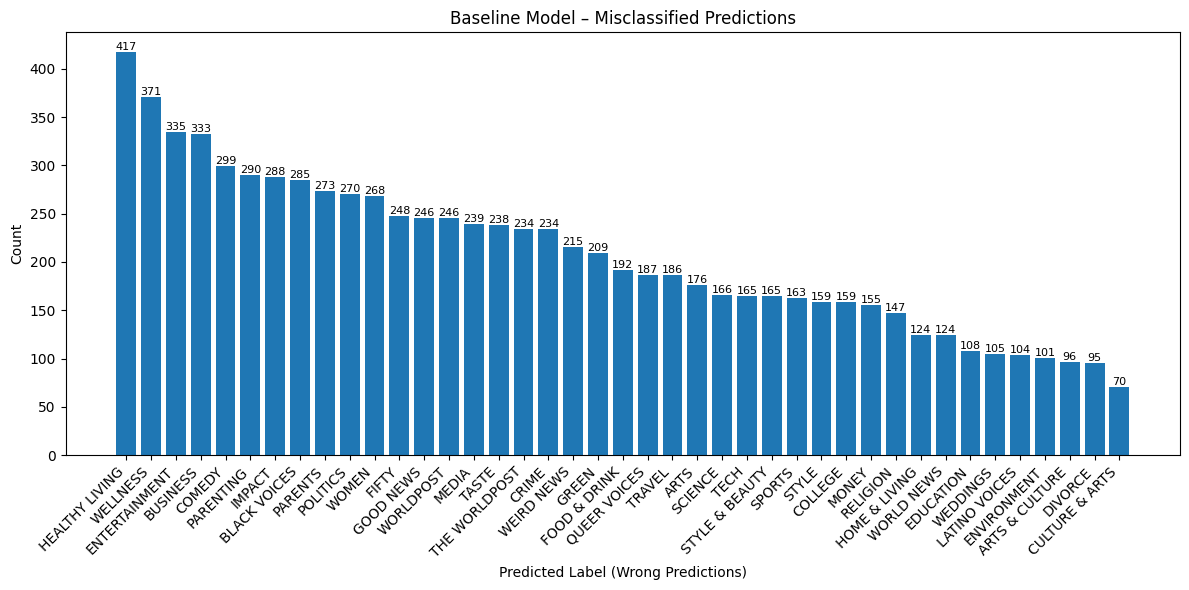

In [46]:
label_2_id = {i: label for label, i in label_2.items()}
misclassified_baseline = []

model.eval()

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)

        outputs = model(input_ids)
        preds = torch.argmax(outputs, dim=1)

        for i in range(len(preds)):
            if preds[i] != labels[i]:
                misclassified_baseline.append((
                    input_ids[i].cpu(),
                    labels[i].item(),
                    preds[i].item()
                ))

pred_counts = Counter()

for _, true, pred in misclassified_baseline:
    pred_counts[pred] += 1

sorted_counts = sorted(pred_counts.items(), key=lambda x: x[1], reverse=True)

labels = [label_2_id[p] for p, _ in sorted_counts]
counts = [c for _, c in sorted_counts]

plt.figure(figsize=(12,6))
bars = plt.bar(labels, counts)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             str(height), ha='center', va='bottom', fontsize=8)

plt.xticks(rotation=45, ha='right')
plt.title("Baseline Model – Misclassified Predictions")
plt.xlabel("Predicted Label (Wrong Predictions)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

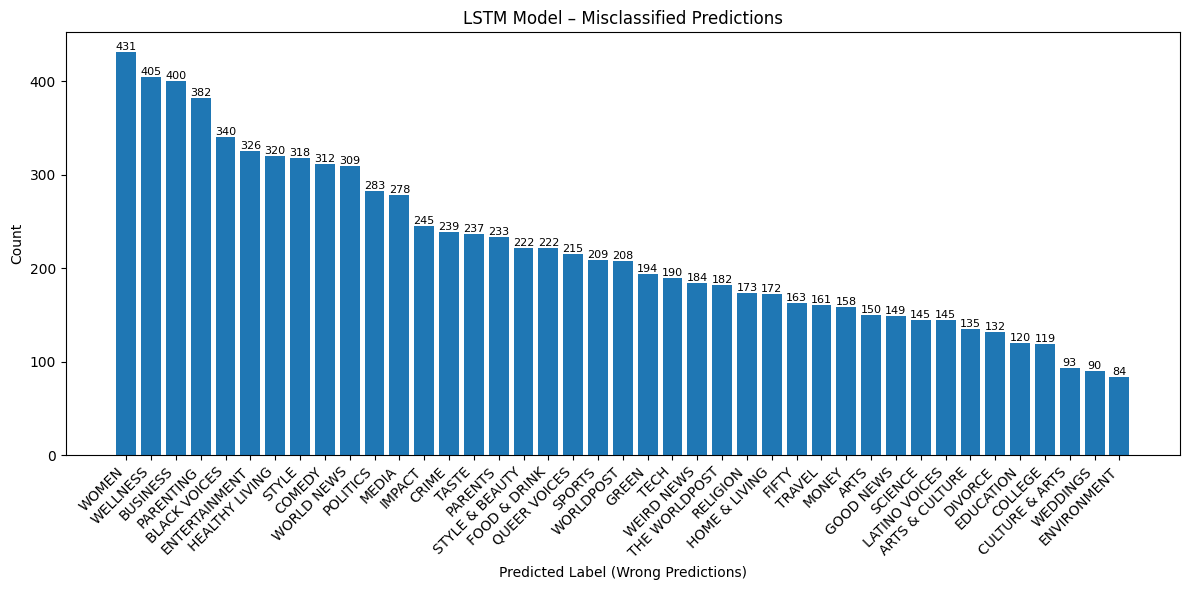

In [47]:
misclassified_lstm = []

custom_model.eval()

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)

        outputs = custom_model(input_ids)
        preds = torch.argmax(outputs, dim=1)

        for i in range(len(preds)):
            if preds[i] != labels[i]:
                misclassified_lstm.append((
                    input_ids[i].cpu(),
                    labels[i].item(),
                    preds[i].item()
                ))

pred_counts = Counter()

for _, true, pred in misclassified_lstm:
    pred_counts[pred] += 1

sorted_counts = sorted(pred_counts.items(), key=lambda x: x[1], reverse=True)

labels = [label_2_id[p] for p, _ in sorted_counts]
counts = [c for _, c in sorted_counts]

plt.figure(figsize=(12,6))
bars = plt.bar(labels, counts)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             str(height), ha='center', va='bottom', fontsize=8)

plt.xticks(rotation=45, ha='right')
plt.title("LSTM Model – Misclassified Predictions")
plt.xlabel("Predicted Label (Wrong Predictions)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [48]:
# looking for classes that were challenging in DB model

misclassified = []

DB_model.eval()

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)

        attention_mask = batch["attention_mask"].to(device)
        outputs = DB_model(input_ids=input_ids, attention_mask=attention_mask)

        preds = torch.argmax(outputs.logits, dim=1)

        for i in range(len(preds)):
            if preds[i] != labels[i]:
                misclassified.append((
                    input_ids[i].cpu(),
                    labels[i].item(),
                    preds[i].item()
                ))


In [49]:
label_2_id = {i: label for label, i in label_2.items()}

for i in range(5): # show 5 examples of misclassified rows
    tokens, true_label, pred_label = misclassified[i]

    text = tokenizer.decode(tokens, skip_special_tokens=True)

    print("TEXT:", text)
    print("TRUE:", label_2_id[true_label])
    print("PRED:", label_2_id[pred_label])
    print("-"*50)

TEXT: ' boulevard ' star roberto aguire on working with robin williams in last dramatic role [ sep ] " the great thing about robin is, after you had the chance to meet him, that ’ s exactly who he was. "
TRUE: LATINO VOICES
PRED: ENTERTAINMENT
--------------------------------------------------
TEXT: use the good stuff [ sep ] i told her that when my husband left, he didn ' t ask for anything. not a single photograph. not any artwork the kids had made. he wanted nothing, not a single remnant nor reminder of our 15 years together.
TRUE: DIVORCE
PRED: PARENTING
--------------------------------------------------
TEXT: coco chanel ' s apartment, martha stewart ' s yearbook pic and more instagrams of the week ( photos ) [ sep ] it ' s the end of the week and that means we ' re taking a look back at the best instagrams from our favorite designers
TRUE: HOME & LIVING
PRED: STYLE & BEAUTY
--------------------------------------------------
TEXT: inside the world of an event planner : behind the 

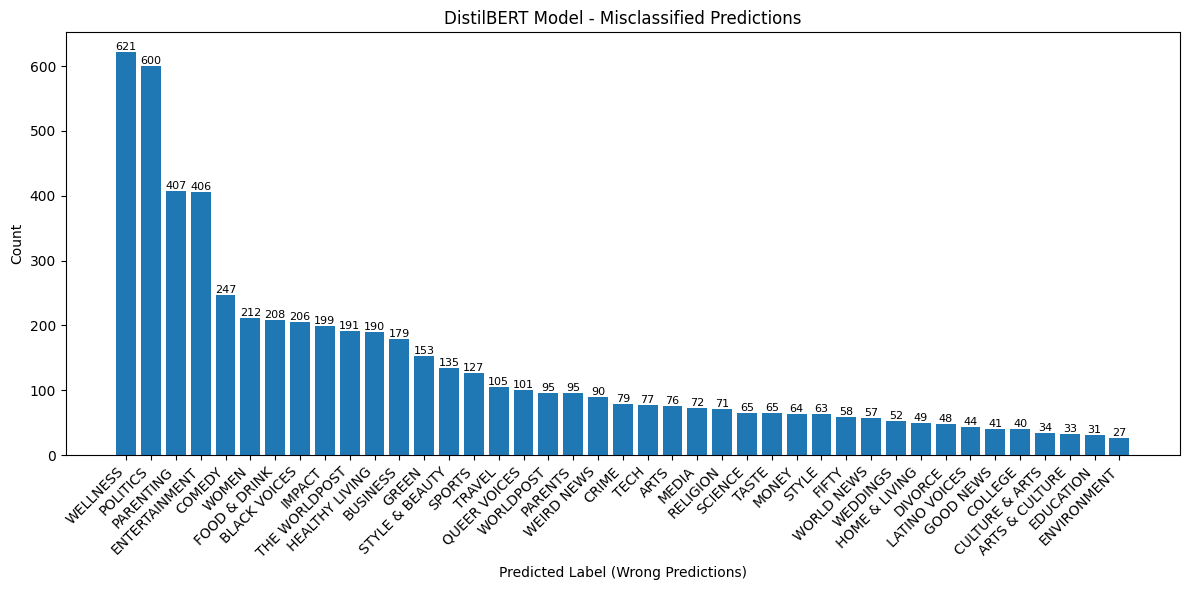

In [50]:

# plotting misclassfied labels from DB model
pred_counts = Counter()

for _, true, pred in misclassified:
    pred_counts[pred] += 1

sorted_counts = sorted(pred_counts.items(), key=lambda x: x[1], reverse=True)

labels = [label_2_id[p] for p, _ in sorted_counts]
counts = [c for _, c in sorted_counts]

plt.figure(figsize=(12,6))
bars = plt.bar(labels, counts)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             str(height), ha='center', va='bottom', fontsize=8)

plt.xticks(rotation=45, ha='right')
plt.title("DistilBERT Model - Misclassified Predictions")
plt.xlabel("Predicted Label (Wrong Predictions)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Graded Questions (4 pts each)

1. **Summary Table and Performance Analysis:** Present a clear quantitative comparison of all three models. Which model achieved the best overall results, and what factors contributed to its success?

In [52]:
results_df

,Model,Test Accuracy,Best Validation Accuracy,Training Time (s),F1 Score,Parameters
0,Baseline,0.576153,0.579928,178.293657,0.494694,3912105
1,Custom,0.546781,0.544760,189.195041,0.467886,4011433
2,Pretrained,0.714621,0.716006,610.115083,0.619537,66985001


5.1. **Your answer here:**

The pretrained DistilBERT model performed the best across all metrics, achieving the highest validation accuracy (0.7160) and test accuracy (0.7146). The baseline model performed moderately well with a test accuracy of 0.5761, while the custom bidirectional LSTM model performed slightly worse at 0.5467. The DistilBERT model was able to perform better than the baseline and LSTM model because it leveraged pretrained contextual represenations which allowed the model to better understand the text.

2. **Trade-Offs:** Discuss how complexity, accuracy, and efficiency balanced across your models.

5.2. **Your answer here:**

The baseline model was the most efficient with the smallest size and fastest training time but it had lower performance. The LSTM model increased complexity, but it did not improve accuracy which suggested diminishing returns without proper tuning. The DistilBERT model required a lot more paramters and training time but it did deliver much higher accuracy and better generalization. The performance of these models shows the trade off between computational cost and performance.

3. **Error Patterns:** Describe the types of examples or classes that remained challenging for all models.

5.3. **Your answer here:**

The models showed different behavior when learning from the dataset. All models struggled with less frequent classes due to class imbalance in the dataset. The baseline and the LSTM models had more difficulty differing between similar categories which lead to more misclassifications. [Distil]BERT reduced these misclassifications but it still showed confusion among the closely related classes.

In milestone 1, we examined that the potentially confusing categories were POLITICS vs WORLD NEWS, WELLNESS vs HEALTHY LIVING, and STYLE vs STYLE & BEAUTY.

The Baseline Model - Misclassified Predictions bar chart shows that HEALTHY LIVING and WELLNESS were among the top 5 misclassified labels.

The LSTM - Misclassified Predictions bar chart shows that WOMEN, IMPACT, and PARENTING were the top 3 misclassifed labels which we did not exepct from our eda.

The DistilBERT - Misclassified Predictions bar chart shows that POLITICS and WELNESS were the top 2 misclassifed labels which aligns with our suspicions from milstone 1.

These examples remained challenging for the models.classes.

4. **Next Steps:** Based on these findings, decide on a model to go forward with and outline your plan for improving that model.


5.4 **Your answer here:**

Based on these findings, we would choose the DistilBERT model to go forward with. Future improvements could include further fine-tuning of the pretrained model, such as adjusting learning rates, experimenting with partial layer freezing, or increasing training epochs. We would also consider improving class balance or using data augmentation to reduce errors on the minority class. Overall, using pretrained models while carefully tuning hyperparameters appears to be the most promising direction for this task.

### Final Question: Describe what use you made of generative AI tools in preparing this Milestone.

**AI Question: Your answer here:**

We used generative AI tools to debug code and also assist with generating plotting and graphing functions.